## Deprecated SDK imports removed

This project no longer depends on `bigdata-client` or `bigdata-research-tools`. See **MIGRATION_NOTES.md** / **README.md** and [Thematic_Screener_CLI](../Thematic_Screener_CLI/) for the REST + `bigdata-smart-batching` + OpenAI pattern. Pass crypto entity CSVs (`data/top_15_cryptos.csv`) instead of watchlists.


 # Crypto Adoption Analysis


Identify cryptocurrencies positioned to benefit from institutional adoption ahead of broader market recognition. This workflow adapts our proven equity research screening methodology to digital assets, systematically identifying cryptocurrencies genuinely aligned with key institutional adoption drivers.
​


 ## Why It Matters

Crypto institutional adoption is accelerating rapidly, but identifying which digital assets stand to benefit most requires analyzing vast amounts of information from news, regulatory updates, and market data. Manual analysis is inefficient and prone to bias. As institutional capital enters the market, the window to identify well-positioned cryptocurrencies before mass recognition is narrowing. A systematic, data-driven approach is essential to uncover emerging leaders ahead of the crowd.

 ## What It Does



The ThematicScreener class delivers institutional-grade thematic intelligence at scale. Designed for analysts, PMs, and strategists managing thematic portfolios or scouting new ideas, it systematically connects different assets to investment themes using unstructured data from news, earnings calls, and filings.
​



 ## How It Works



 ThematicScreener follows a systematic 4-step workflow to transform investment themes into actionable intelligence:
- Mindmap Theme Taxonomy - LLM-powered breakdown of investment themes into specific, measurable sub-categories using automated theme tree generation
- Search with Premium Sources - Semantic content retrieval leveraging our dedicated Crypto Wire source, delivering ‘gold-standard’ quality, topicality, volume, source diversity, coverage and timeliness for comprehensive digital asset intelligence
- Label Results - LLM-based classification to analyze text chunks and determine relevance to sub-themes, filtering out content not explicitly linked to the main theme
- Post-process & Score - Qualitative-to-quantitative transformation that aggregates thematic signals into structured scoring methodologies for portfolio-level assessment



 ## A Real-World Use Case



This cookbook demonstrates a systematic approach for identifying institutional adoption trends across 15 major cryptocurrencies, leveraging our dedicated Crypto Wire source. The workflow enables early detection of digital assets positioned to benefit from increasing institutional capital flows, delivering actionable insights before these trends become widely apparent.


 ## Async Compatibility Setup



 **Run this cell first** - Required for Google Colab, Jupyter Notebooks, and VS Code with Jupyter extension:



 ### Why is this needed?



 Interactive environments (Colab, Jupyter) already have an asyncio event loop running. When bigdata-research-tools makes async API calls (like to OpenAI), you'll get this error without nest_asyncio:



 ```

 RuntimeError: asyncio.run() cannot be called from a running event loop

 ```



 The `nest_asyncio.apply()` command patches this to allow nested event loops.



 💡 **Tip**: If you're unsure which environment you're in, just run the cell below - it won't hurt in any environment!

In [1]:
import datetime
start = datetime.datetime.now()

try:
    import asyncio
    asyncio.get_running_loop()
    import nest_asyncio; nest_asyncio.apply()
    print("✅ nest_asyncio applied")
except (RuntimeError, ImportError):
    print("✅ nest_asyncio not needed or not available")


✅ nest_asyncio applied


 ## Environment Setup



 The following cell configures the necessary path for the analysis

In [2]:
import os
import sys

current_dir = os.getcwd()
if current_dir not in sys.path:
    sys.path.append(current_dir)
print(f"✅ Local environment setup complete")


✅ Local environment setup complete


 ## Load Credentials

In [3]:
from dotenv import load_dotenv
from pathlib import Path

script_dir = Path(__file__).parent if '__file__' in globals() else Path.cwd()
load_dotenv(script_dir / '.env')

BIGDATA_API_KEY = os.getenv('BIGDATA_API_KEY')
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')

if not all([BIGDATA_API_KEY, OPENAI_API_KEY]):
    print("❌ Missing required environment variables")
    raise ValueError("Missing required environment variables. Check your .env file.")
else:
    print("✅ Credentials loaded from .env file")


✅ Credentials loaded from .env file


 ## Import Required Libraries

In [4]:
import json
import pandas as pd
from openai import OpenAI

from src.bigdata_rest import BigdataRestClient, load_crypto_universe
from src.openai_utils import sampling_params_for_model
from src.search_entities import search_by_entities, post_process_dataframe

# REST client (X-API-KEY auth) + OpenAI client replace bigdata-client / bigdata-research-tools
rest_client = BigdataRestClient(api_key=BIGDATA_API_KEY)
openai_client = OpenAI(api_key=OPENAI_API_KEY)
print("✅ REST + OpenAI clients ready")

✅ REST + OpenAI clients ready


 ## Optional: Plotly Display Configuration



 For better visualization rendering, you can also set the Plotly renderer:

In [5]:
import plotly.io as pio

# Try to detect the environment and set appropriate renderer
try:
    # Check if we're in JupyterLab
    import os
    if 'JUPYTERHUB_SERVICE_PREFIX' in os.environ or 'JPY_SESSION_NAME' in os.environ:
        pio.renderers.default = 'jupyterlab'
        print("✅ Plotly configured for JupyterLab")
    else:
        # Default for VS Code, Jupyter Notebook, etc.
        pio.renderers.default = 'plotly_mimetype+notebook'
        print("✅ Plotly configured for Jupyter/VS Code")
except:
    # Fallback to a more universal renderer
    pio.renderers.default = 'notebook'
    print("✅ Plotly configured with fallback renderer")


✅ Plotly configured for Jupyter/VS Code


 ## Define Output Paths



 We define the output paths for our thematic screening results.

In [6]:
# Define output file paths for our results
output_dir = "output"
os.makedirs(output_dir, exist_ok=True)

export_path = f"{output_dir}/thematic_screener_results.xlsx"


 ## Connecting to Bigdata



 We authenticate directly against the Bigdata.com REST API (`X-API-KEY` header) instead of the deprecated SDK client. The `rest_client` / `openai_client` objects were created above.


In [7]:
# rest_client / openai_client were already created in the imports cell above.
print(f"✅ Connected to {rest_client.base_url}")


✅ Connected to https://api.bigdata.com


## Defining your Screening Parameters

- **Main Theme** (`main_theme`): The central concept to explore
- **Entity Universe** (`entity_ids` / `entity_names`): Top 15 cryptocurrencies loaded from `data/top_15_cryptos.csv` (`RP_ENTITY_ID`, `ENTITY_NAME`)
- **Time Period** (`start_date` and `end_date`): The date range over which to run the search
- **Document Limit** (`document_limit`): The maximum number of documents to return per entity/theme query to the Bigdata API
- **Model Selection** (`llm_model`): The OpenAI model used to generate the theme taxonomy and label the search result chunks


In [8]:
# ===== Theme Definition =====
main_theme = "Crypto Institutional Adoption"
focus = "Include know your customer (KYC) and anti-money laundering (AML) themes"

# ===== Entity Universe (Top 15 Cryptos CSV) =====
universe_path = "data/top_15_cryptos.csv"
entity_ids, entity_names = load_crypto_universe(universe_path)

# ===== LLM Specification =====
llm_model = "gpt-5.6-luna"

# ===== Specify Time Range =====
start_date = "2025-01-01"
end_date = "2025-09-08"

print(f"Cryptos ({len(entity_ids)}): {list(entity_names.values())}")


Cryptos (15): ['Arbitrum', 'Bitcoin', 'BNB (BNB)', 'Cardano (ADA)', 'Dino', 'Dogecoin', 'Ethereum', 'Hyperliquid', 'Litecoin', 'POL (ex-MATIC)', 'Shiba Inu', 'Solana (SOL)', 'Tether', 'TRON', 'XRP (XRP)']


 ## Mindmap a Theme Taxonomy with OpenAI



 `bigdata-research-tools`' `generate_theme_tree` is no longer available. We replicate the same idea with a direct OpenAI call: break the main theme down into a handful of specific, measurable sub-themes expressed as descriptive sentences.


In [9]:
def generate_themes(main_theme: str, focus: str = "", n_themes: int = 5) -> list[str]:
    """Generate a small theme taxonomy using OpenAI (replaces bigdata_research_tools.generate_theme_tree)."""
    prompt = f'''Generate {n_themes} specific, measurable sub-themes for analyzing: "{main_theme}"

{"Focus: " + focus if focus else ""}

Each sub-theme should be a short descriptive sentence that explicitly connects back to the main theme.
Return ONLY a JSON array of strings, e.g.:
["Sub-theme sentence 1", "Sub-theme sentence 2"]
'''
    response = openai_client.chat.completions.create(
        model=llm_model,
        messages=[{"role": "user", "content": prompt}],
        **sampling_params_for_model(llm_model, temperature=0.3),
    )
    text = response.choices[0].message.content.strip()
    if text.startswith("```"):
        text = text.split("```")[1]
        if text.startswith("json"):
            text = text[4:]
        text = text.strip()
    return json.loads(text)


node_summaries = generate_themes(main_theme, focus=focus, n_themes=5)
for sentence in node_summaries:
    print("-", sentence)


- Measure institutional crypto adoption by the percentage of platforms implementing automated KYC verification for new institutional clients.
- Compare institutional crypto onboarding rates across jurisdictions based on the time required to complete KYC and AML checks.
- Assess how AML transaction-monitoring coverage influences the volume and value of institutional crypto trading activity.
- Track institutional adoption through the percentage of crypto service providers meeting defined AML compliance and suspicious-activity reporting standards.
- Evaluate the relationship between institutional crypto asset inflows and the number of KYC- and AML-cleared institutional accounts over time.


 Each generated sentence explicitly connects a sub-theme back to the main theme, so both the search step and the labeling step stay contextually anchored to "Crypto Institutional Adoption".


In [10]:
# In this simplified REST pipeline the same sentences double as search queries
# and as the label taxonomy handed to the OpenAI labeler below.
labels = node_summaries


 ## Retrieve Content using Bigdata’s Search Capabilities



 With the theme taxonomy and screening parameters defined, we call `search_by_entities` (`src/search_entities.py`), which issues one `/v1/search` REST call per entity/theme-sentence combination and returns a chunk-level DataFrame.

 -  **Document Limit** (``document_limit``): The maximum number of documents to return per query to the Bigdata API. Kept small for cost control.


In [11]:
# Cost control: small per-query document cap
document_limit = 10


In [12]:
df_sentences = search_by_entities(
    entity_ids=entity_ids,
    entity_names=entity_names,
    sentences=node_summaries,
    start_date=start_date,
    end_date=end_date,
    rest_client=rest_client,
    document_limit=document_limit,
)

print(f"Retrieved {len(df_sentences)} chunk-level rows")
df_sentences.head()


Searching entities:   0%|          | 0/15 [00:00<?, ?it/s]

Searching entities:   7%|▋         | 1/15 [00:07<01:38,  7.02s/it]

Searching entities:  13%|█▎        | 2/15 [00:11<01:13,  5.68s/it]

Searching entities:  20%|██        | 3/15 [00:16<01:01,  5.15s/it]

Searching entities:  27%|██▋       | 4/15 [00:21<00:57,  5.21s/it]

...

Searching entities:  93%|█████████▎| 14/15 [01:15<00:04,  4.71s/it]

Searching entities: 100%|██████████| 15/15 [01:20<00:00,  4.84s/it]

Searching entities: 100%|██████████| 15/15 [01:20<00:00,  5.37s/it]

Retrieved 30 chunk-level rows


,timestamp_utc,document_id,sentence_id,headline,entity_id,entity_name,text
0,2025-01-24 21:20:21,6DE70F49A61A09F6C0390F87CAA88423,6DE70F49A61A09F6C0390F87CAA88423-0,CoinShares Litecoin ETF files FORM S-1 on Jan ...,23B972,Litecoin,LTC trading venues that are regulated typicall...
1,2025-02-21 08:51:13,5DC5D3EAAD45EE968588C8A26D151479,5DC5D3EAAD45EE968588C8A26D151479-0,"""The Knee on Crypto's Neck is Lifting"": Hidden...",9D4B6F,Tether,The European Union is another concern. MiCA is...
2,2025-02-27 00:00:00,FE35C504F1CE7905F604D14F96E528DE,FE35C504F1CE7905F604D14F96E528DE-0,SS&C Technologies Holdings Inc. - Will 2025 Be...,A25816,Bitcoin,What Could Change for Crypto?\nThe next year c...
3,2025-03-19 09:13:02,95572F4087168765F7FEECA3FD8A9261,95572F4087168765F7FEECA3FD8A9261-0,Coinbase's new KYC verified pools aim to forti...,A25816,Bitcoin,Rising institutional interest\nThe launch of V...
4,2025-03-19 09:13:02,95572F4087168765F7FEECA3FD8A9261,95572F4087168765F7FEECA3FD8A9261-0,Coinbase's new KYC verified pools aim to forti...,BF05E7,Solana (SOL),Rising institutional interest\nThe launch of V...


 ## Label the Results



 `bigdata_research_tools.labeler.ScreenerLabeler` is no longer available. We replicate its behavior with a direct OpenAI call per text chunk, asking the model to pick the closest matching sub-theme (or `"unclear"` if none apply). Chunks labeled `"unclear"` are filtered out by `post_process_dataframe`.

 Cost control: only a small sample of retrieved chunks is sent to OpenAI for labeling.


In [13]:
def label_crypto_text(text: str, entity_name: str, themes: list[str]) -> dict:
    """Classify a text chunk against the theme taxonomy using OpenAI (replaces ScreenerLabeler)."""
    prompt = f'''Analyze this text about {entity_name} and identify which theme it relates to most.

Themes: {", ".join(themes)}

Text: {text}

Return JSON: {{"label": "the closest matching theme, verbatim, or \'unclear\'", "motivation": "brief one-sentence explanation"}}
'''
    response = openai_client.chat.completions.create(
        model=llm_model,
        messages=[{"role": "user", "content": prompt}],
        response_format={"type": "json_object"},
        **sampling_params_for_model(llm_model, temperature=0.0),
    )
    return json.loads(response.choices[0].message.content)


# Label full retrieved set
MAX_ROWS_TO_LABEL = 10_000
if len(df_sentences) > MAX_ROWS_TO_LABEL:
    df_sentences = df_sentences.head(MAX_ROWS_TO_LABEL).reset_index(drop=True)

if not df_sentences.empty:
    label_results = df_sentences.apply(
        lambda row: label_crypto_text(row["text"], row["entity_name"], node_summaries),
        axis=1,
    )
    df_sentences["label"] = label_results.apply(lambda x: x.get("label", "unclear"))
    df_sentences["motivation"] = label_results.apply(lambda x: x.get("motivation", ""))
else:
    df_sentences["label"] = pd.Series(dtype=str)
    df_sentences["motivation"] = pd.Series(dtype=str)

print(f"Labeled {len(df_sentences)} rows")
df_sentences.head()


Labeled 30 rows


,timestamp_utc,document_id,sentence_id,headline,entity_id,entity_name,text,label,motivation
0,2025-01-24 21:20:21,6DE70F49A61A09F6C0390F87CAA88423,6DE70F49A61A09F6C0390F87CAA88423-0,CoinShares Litecoin ETF files FORM S-1 on Jan ...,23B972,Litecoin,LTC trading venues that are regulated typicall...,Track institutional adoption through the perce...,The text discusses AML requirements for regula...
1,2025-02-21 08:51:13,5DC5D3EAAD45EE968588C8A26D151479,5DC5D3EAAD45EE968588C8A26D151479-0,"""The Knee on Crypto's Neck is Lifting"": Hidden...",9D4B6F,Tether,The European Union is another concern. MiCA is...,Track institutional adoption through the perce...,"The text focuses on KYC, due diligence, financ..."
2,2025-02-27 00:00:00,FE35C504F1CE7905F604D14F96E528DE,FE35C504F1CE7905F604D14F96E528DE-0,SS&C Technologies Holdings Inc. - Will 2025 Be...,A25816,Bitcoin,What Could Change for Crypto?\nThe next year c...,Evaluate the relationship between institutiona...,The text discusses regulatory clarity potentia...
3,2025-03-19 09:13:02,95572F4087168765F7FEECA3FD8A9261,95572F4087168765F7FEECA3FD8A9261-0,Coinbase's new KYC verified pools aim to forti...,A25816,Bitcoin,Rising institutional interest\nThe launch of V...,unclear,The text discusses rising institutional crypto...
4,2025-03-19 09:13:02,95572F4087168765F7FEECA3FD8A9261,95572F4087168765F7FEECA3FD8A9261-0,Coinbase's new KYC verified pools aim to forti...,BF05E7,Solana (SOL),Rising institutional interest\nThe launch of V...,unclear,The text discusses growing institutional inter...


In [14]:
# No merge needed: labeling above wrote "label"/"motivation" directly onto df_sentences
df = df_sentences.copy()


In [15]:
df = post_process_dataframe(df)

 ## Assess Thematic Exposure Across Your Entities

 We’ll look at the most exposed companies to our main theme. `score_entities` (defined below) replaces `bigdata_research_tools.workflows.utils.get_scored_df`: it counts, per entity, how many labeled chunks fall under each sub-theme, then sums them into a composite thematic score (`df_entity`).


In [16]:
def score_entities(df: pd.DataFrame, themes: list[str]) -> pd.DataFrame:
    """Aggregate thematic signal counts per entity (replaces bigdata_research_tools.get_scored_df)."""
    rows = []
    for entity in df["Entity"].unique():
        entity_df = df[df["Entity"] == entity]
        theme_counts = {theme: int((entity_df["Theme"] == theme).sum()) for theme in themes}
        row = {
            "Entity": entity,
            "Total Mentions": len(entity_df),
            "Themes Covered": sum(1 for count in theme_counts.values() if count > 0),
            **theme_counts,
            "Composite Score": sum(theme_counts.values()),
        }
        rows.append(row)
    return (
        pd.DataFrame(rows)
        .sort_values("Composite Score", ascending=False)
        .reset_index(drop=True)
    )


df_entity = score_entities(df, node_summaries) if not df.empty else pd.DataFrame()
df_entity


,Entity,Total Mentions,Themes Covered,Measure institutional crypto adoption by the percentage of platforms implementing automated KYC verification for new institutional clients.,Compare institutional crypto onboarding rates across jurisdictions based on the time required to complete KYC and AML checks.,Assess how AML transaction-monitoring coverage influences the volume and value of institutional crypto trading activity.,Track institutional adoption through the percentage of crypto service providers meeting defined AML compliance and suspicious-activity reporting standards.,Evaluate the relationship between institutional crypto asset inflows and the number of KYC- and AML-cleared institutional accounts over time.,Composite Score
0,Bitcoin,5,3,1,0,0,3,1,5
1,Tether,5,3,1,2,0,2,0,5
2,TRON,3,1,0,0,3,0,0,3
3,Cardano (ADA),2,1,2,0,0,0,0,2
4,Dogecoin,2,2,1,0,0,1,0,2
5,Ethereum,2,2,0,0,1,1,0,2
6,Litecoin,2,1,0,0,0,2,0,2
7,Arbitrum,1,1,0,0,0,1,0,1
8,POL (ex-MATIC),1,1,0,0,0,1,0,1
9,XRP (XRP),1,1,1,0,0,0,0,1


In [17]:
from src.visualization_tool import display_figures

/Users/franciscogomez/git/bigdata/wt-html-refresh/Screener_for_Crypto/src/visualization_tool.py:66: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


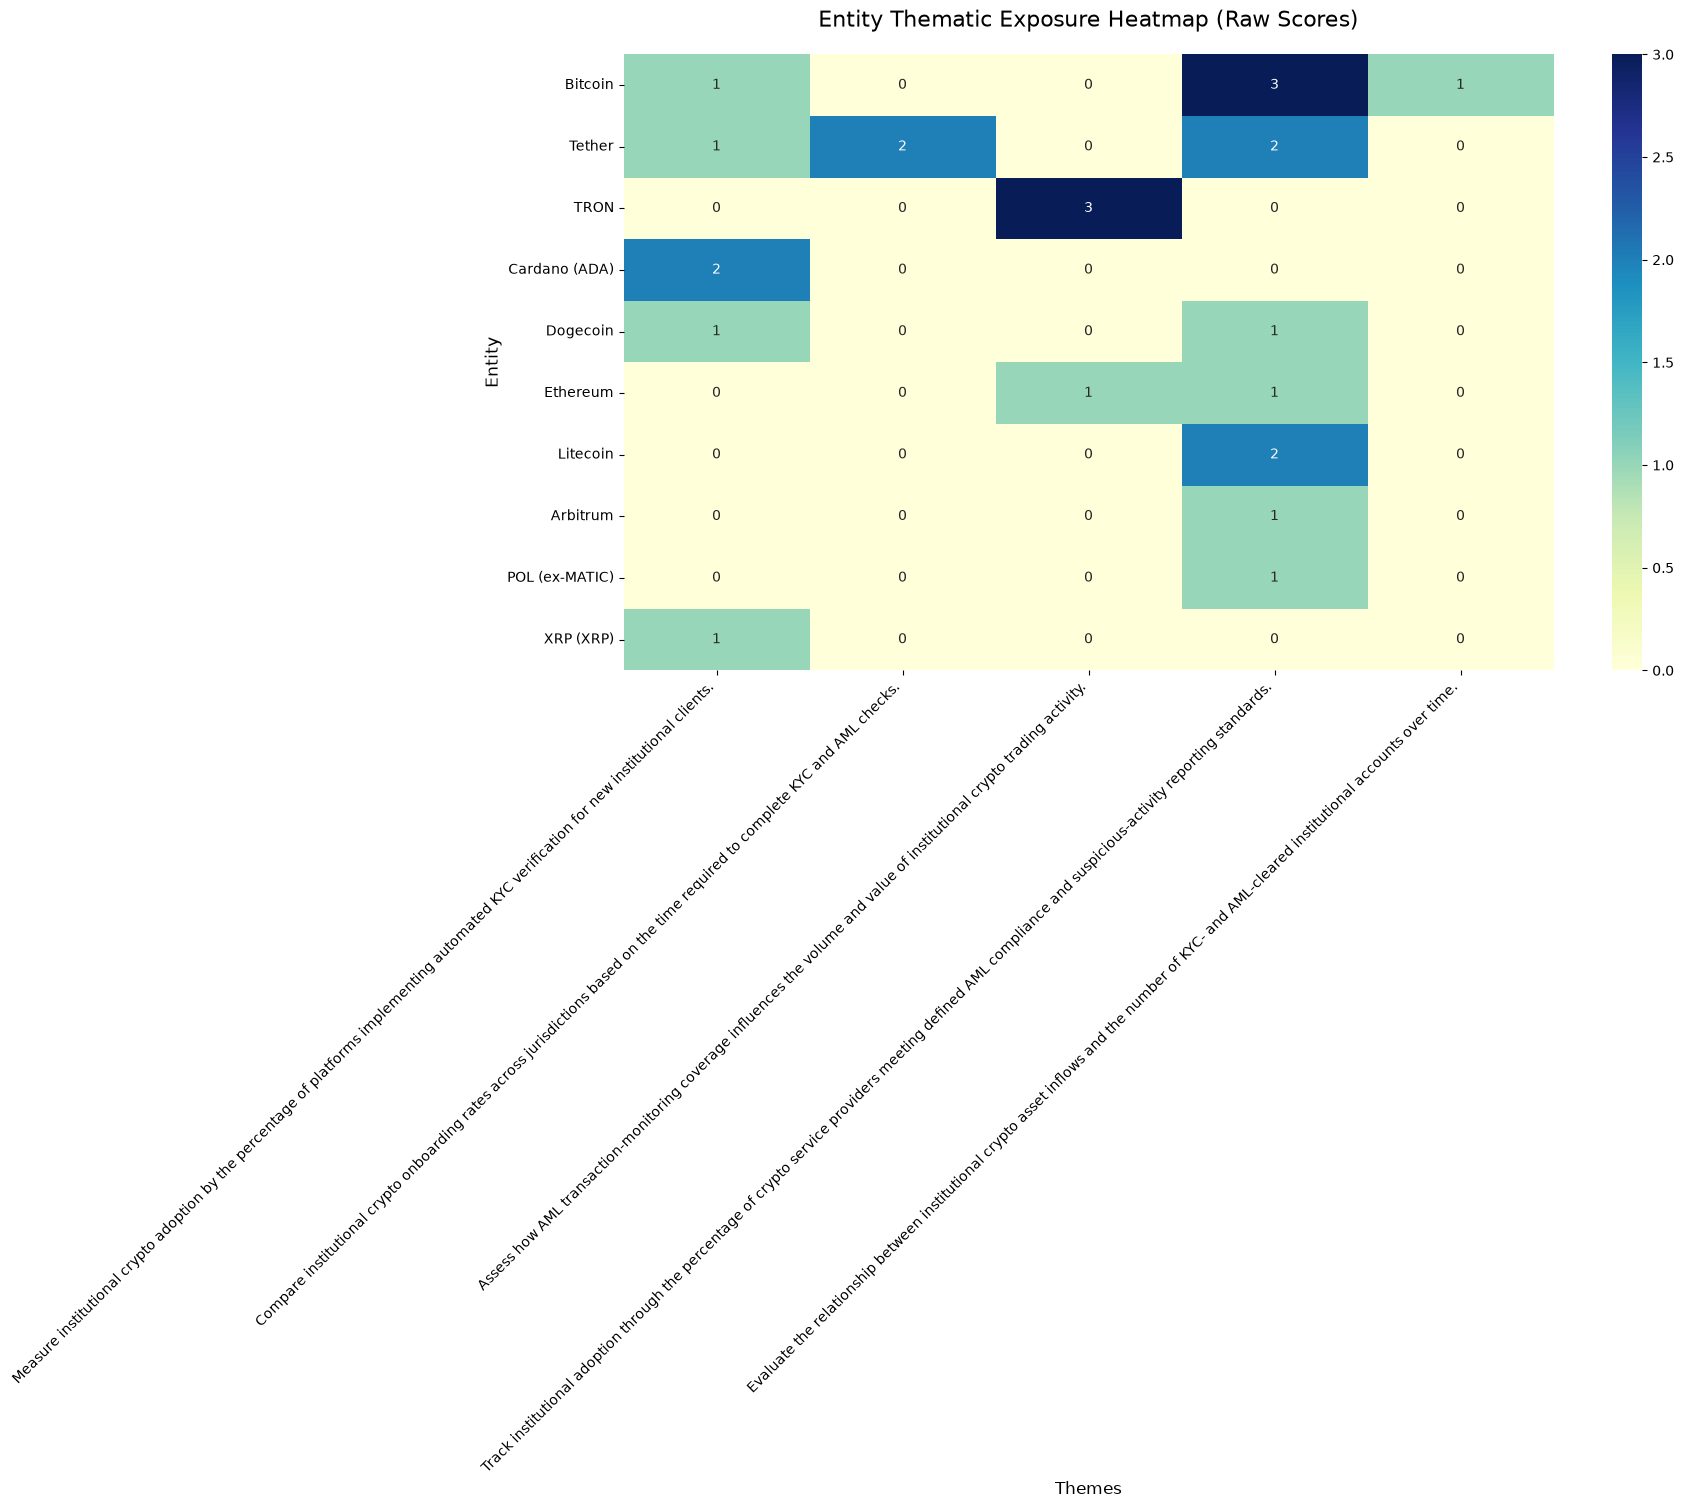

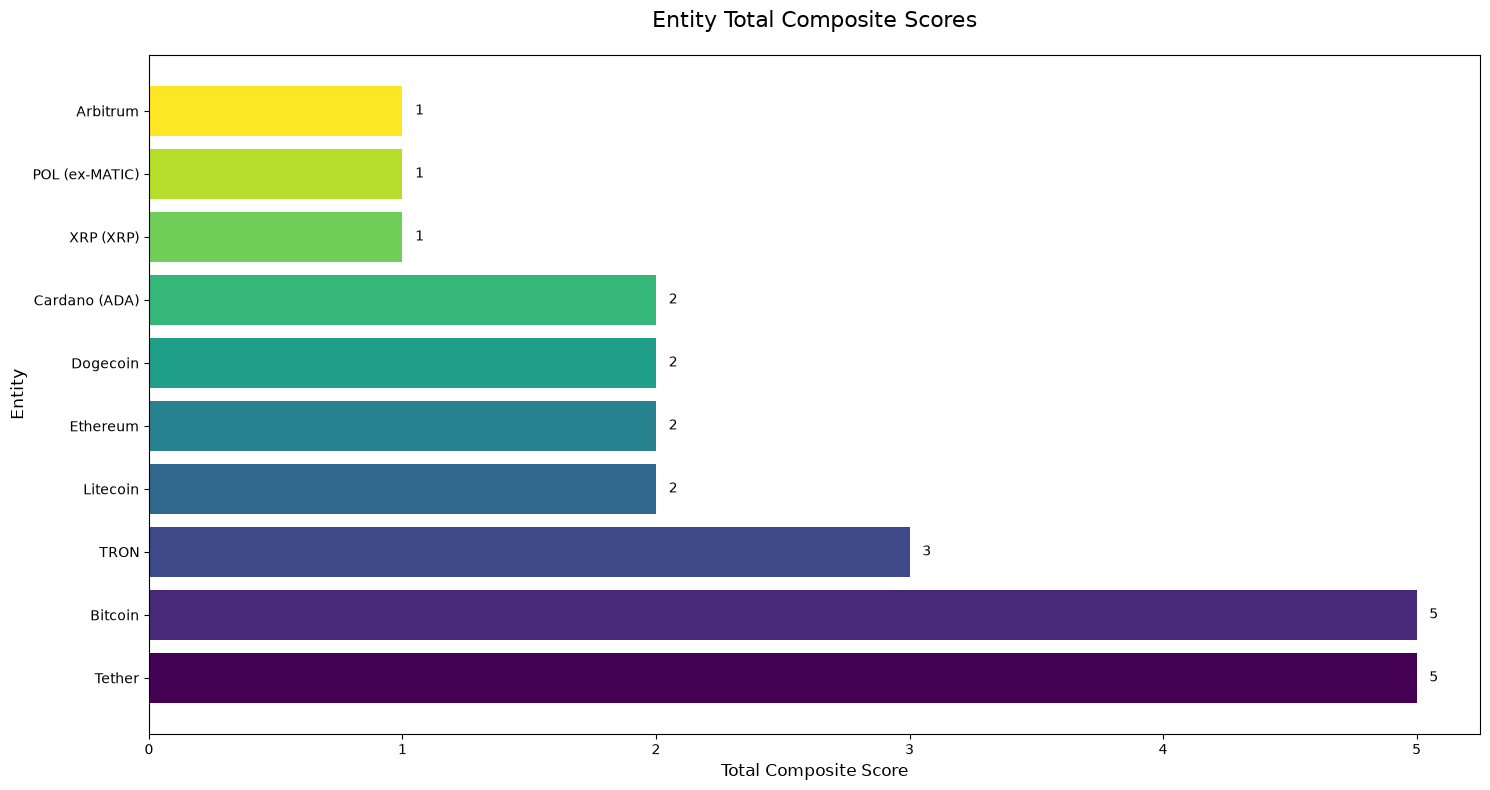

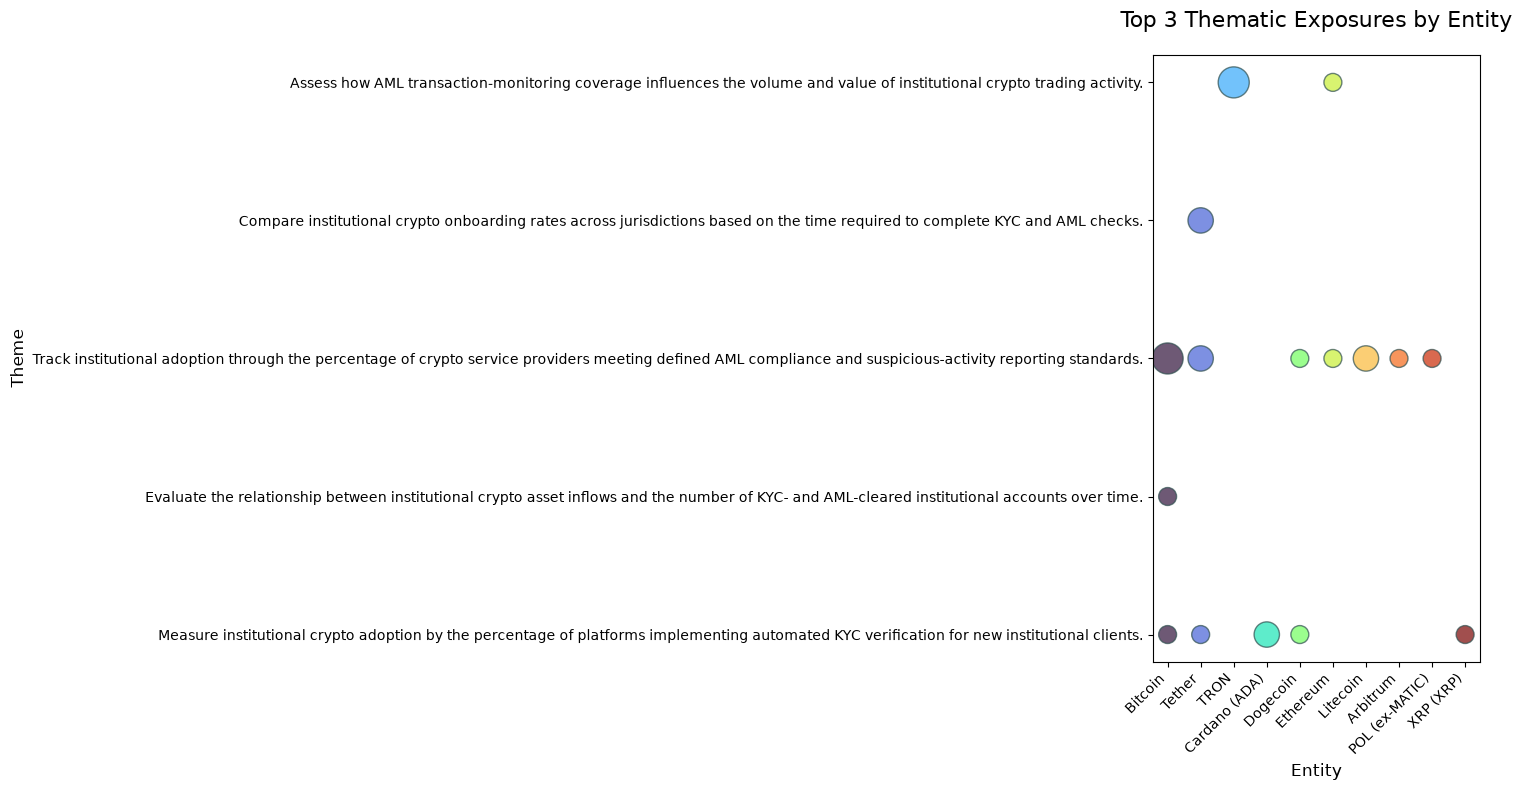

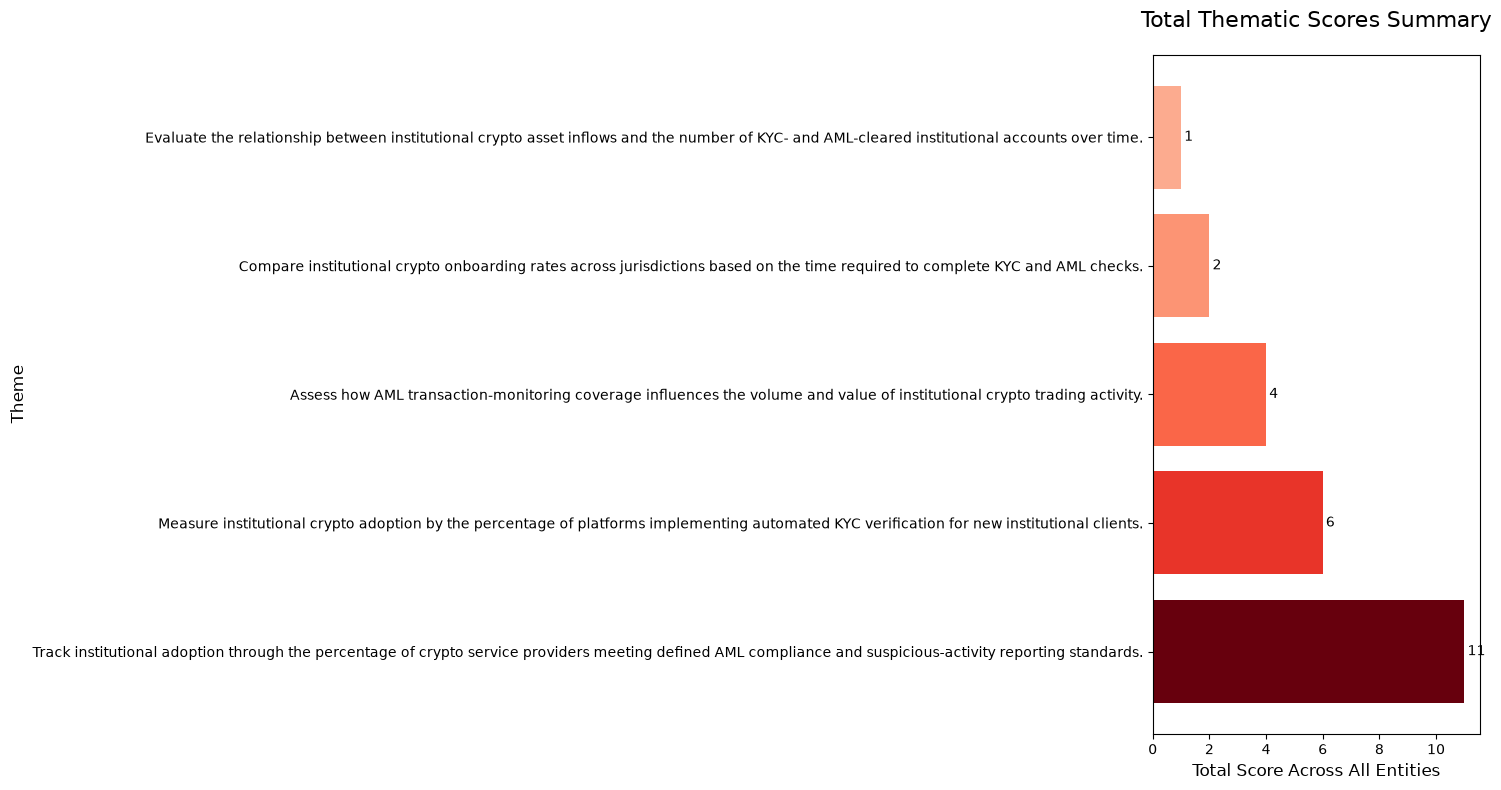

In [18]:
if df_entity.empty:
    print("No labeled thematic data to visualize for this narrow date window/sample.")
else:
    display_figures(df_entity, interactive=False, n_entities=10)
